Nama: Prieyuda Akadita S
NIM: 240401010353
Kelas: IF403

In [1]:
print("IInstall library, harap tunggu....")
!python -m pip install -q pandas seaborn matplotlib scikit-learn
print("Library berhasil diinstall!")

IInstall library, harap tunggu....
Library berhasil diinstall!



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Shape: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


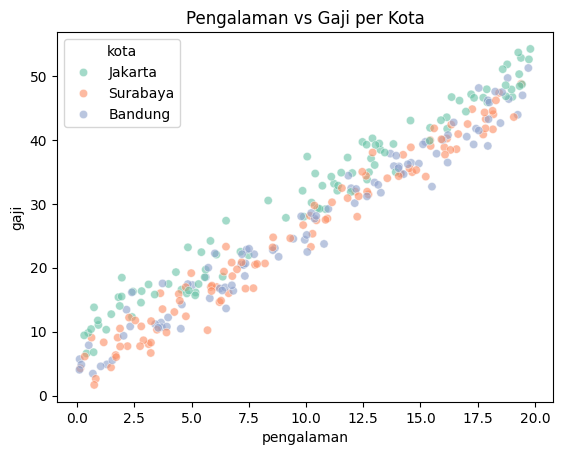

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

# Generate dataset sintetis
np.random.seed(42); n = 300
pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n) # SMA=0, D3=1, S1=2
kota = np.random.choice(['Jakarta','Surabaya','Bandung'], n)
gaji = (3.0 + 2.2*pengalaman + 1.5*edu
 + np.where(kota=='Jakarta', 4.0, 0)
 + np.random.normal(0, 2, n))
df = pd.DataFrame({'pengalaman':pengalaman, 'edu':edu,
 'kota':kota, 'gaji':gaji})
# EDA singkat
print('Shape:', df.shape)
print(df.describe().round(2))
# Scatter: pengalaman vs gaji
sns.scatterplot(data=df, x='pengalaman', y='gaji',
 hue='kota', palette='Set2', alpha=0.6)
plt.title('Pengalaman vs Gaji per Kota')
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# One-Hot Encoding kolom 'kota'
df = pd.get_dummies(df, columns=['kota'],
 drop_first=True, dtype=int)
print('Kolom setelah encoding:', df.columns.tolist())
# Pisahkan fitur dan target
X = df.drop('gaji', axis=1)
y = df['gaji']
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} baris, Test: {X_test.shape[0]} baris')
# StandardScaler — fit pada training set saja
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train: 240 baris, Test: 60 baris


In [4]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train_s, y_train)
# Tampilkan koefisien
print(f'β₀ (intercept): {model.intercept_:.3f}')
print()
coef_df = pd.DataFrame({
 'Fitur' : X.columns,
 'Koefisien' : model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))
# Interpretasi: fitur mana yang paling berpengaruh?
# Koefisien positif → gaji naik
# Koefisien negatif → gaji turun

β₀ (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


Fitur yang paling berpengaruh terhadap gaji adalah pengalaman kerja. Fitur ini memiliki nilai koefisien positif terbesar, yaitu 13,042, yang berarti setiap peningkatan satu satuan pengalaman kerja akan menaikkan gaji sebesar 13,042 juta rupiah dengan asumsi fitur lainnya tetap.

In [5]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

y_pred = model.predict(X_test_s)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R² = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')
# Interpretasikan dalam Markdown sel berikutnya:
# - Berapa rata-rata kesalahan prediksi dalam rupiah?
# - Apakah R² cukup baik untuk kasus ini?
# - Apakah ada indikasi outlier?

=== Metrik Evaluasi ===
MAE = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R² = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474


1. Berapa rata-rata kesalahan prediksi dalam rupiah?


Rata-rata kesalahan prediksi model adalah sebesar 1,649 juta rupiah. Artinya, secara umum prediksi harga dari model bisa meleset lebih tinggi atau lebih rendah sekitar 1,65 juta rupiah dari harga aslinya.

2.   Apakah R² cukup baik untuk kasus ini?

Ya, nilai R² sebesar 0,9740 atau 97,4% sangat baik untuk kasus ini. Angka ini menunjukkan bahwa model mampu menjelaskan 97,4% variasi atau perubahan nilai data target, sedangkan sisanya sebesar 2,6% dipengaruhi oleh faktor lain di luar model.

3. Apakah ada indikasi outlier?

Ya, terdapat indikasi adanya outlier. Hal ini terlihat dari nilai RMSE (2,123) yang lebih besar daripada MAE (1,649) dengan selisih mencapai 0,474. Karena RMSE lebih sensitif dan memberi bobot lebih besar pada kesalahan yang fatal, selisih ini menandakan adanya beberapa data yang nilai prediksinya meleset cukup jauh atau ekstrem (outlier)

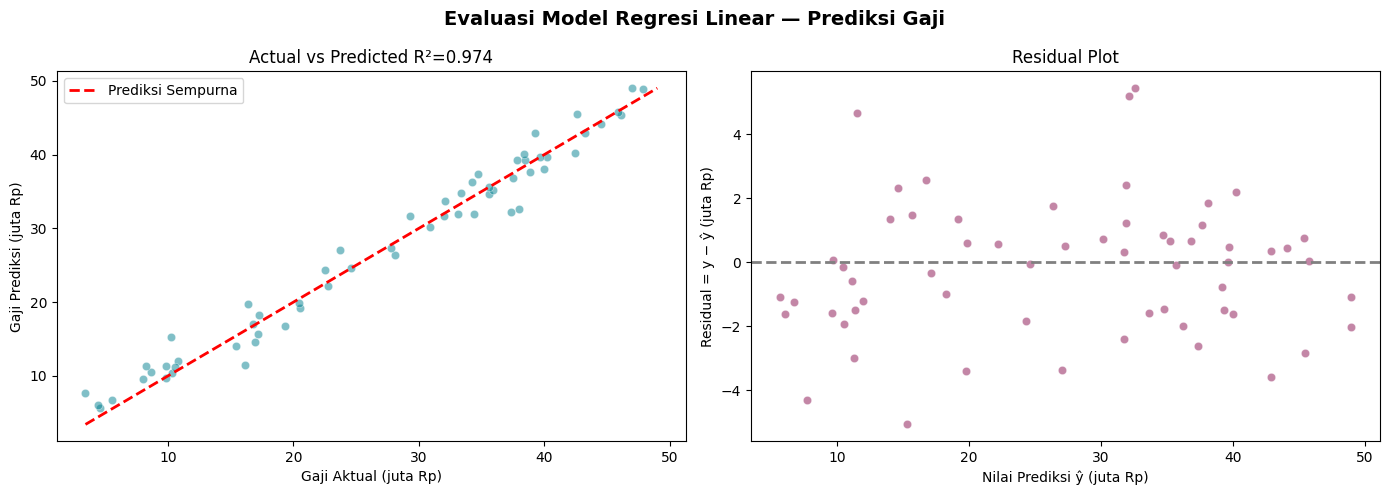

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5,
 color='#028090', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()),
 max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2,
 label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted R²={r2:.3f}')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5,
 color='#880E4F', edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')
plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji',
 fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()